In [1]:
# importación librerias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# carga de archivos
plans = pd.read_csv("/datasets/plans.csv")
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [3]:
# primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


In [6]:
# número de filas y columnas de cada dataset
print ("plans", plans.shape)
print ("users", users.shape)
print ("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:

# inspección de plans con .info
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


In [10]:
# cantidad de valores nulos users
print (users.isna().sum())
print (users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de valores nulos usage
print (usage.isna().sum())
print (usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


In [12]:
# explorando columnas númericas en users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [13]:
# explorando columnas númericas en usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


In [14]:
# exploración de columnas relevantes en users
print (users["city"].unique())
print (users["plan"].unique())

['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
['Basico' 'Premium']


In [15]:
# exploración de columna relevante en usage
print (usage["type"].unique())

['call' 'text']


In [16]:
# conversión a fecha la columna 'reg_date' de users
users["reg_date"] = pd.to_datetime(users["reg_date"], errors="coerce")

In [17]:
# conversión a fecha la columna 'date' de usage
usage["date"] = pd.to_datetime(usage["date"], errors="coerce")


In [18]:
# revisión de años presentes en 'reg_date' de users
users["reg_date"].dt.year.unique()

array([2022, 2026, 2023, 2024])

In [19]:
# revisión de años presentes en 'date' de usage
usage["date"].dt.year.unique()

array([2024.,   nan])

In [20]:
# reemplazo de sentinel de columna age en users
age_mediana = users["age"].median()
print (age_mediana)

47.0


In [21]:
users["age"] = users["age"].replace([-999], pd.NA)
users["age"] = users["age"].fillna(age_mediana)

In [22]:
# verificación de cambios
users["age"].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
# remplazo de sentinel de columna city de users
users["city"] = users["city"].replace(["?"], pd.NA)

In [24]:
# verificación de cambios
users["city"].unique()

array(['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [25]:
# remplazo de fechas futuras en columna reg_date de users
users.loc[users["reg_date"] > "2024-12-31", "reg_date"] = pd.NaT

In [26]:
# verificación de cambios
users["reg_date"].dt.year.unique()

array([2022.,   nan, 2023., 2024.])

In [27]:
# verificación MAR en usage para duration
usage["duration"].isna().groupby(usage["type"]).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [28]:
# verificación MAR en usage para length
usage["length"].isna().groupby(usage["type"]).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

In [29]:
# columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) # conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) # conocer el total de llamadas

In [30]:
# agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",          # Total mensajes
    "is_call": "sum",          # Total llamadas
    "duration": "sum"          # Total minutos
}).reset_index().sort_values(by="user_id")

In [31]:

# resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [32]:
# renombrar columnas 
usage_agg = usage_agg.rename(columns={"is_text" : "cant_mensajes", "is_call" : "cant_llamadas", "duration" : "cant_minutos_llamadas"})

In [33]:
# resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamadas
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [34]:
# conmbinación de la tabla agregada con users
user_profile = pd.merge(users, usage_agg, on=["user_id"], how="inner")
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamadas
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


In [35]:
# Tabla filtrada por datos del 2024
user_profile_2024 = user_profile[user_profile["reg_date"].dt.year == 2024].reset_index()

In [36]:
user_profile_2024["reg_date"].dt.year.unique()

array([2024])

In [37]:
user_profile_2024[
    ["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamadas"]
].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamadas
count,1330.000000,1330.000000,1330.000000,1330.000000
mean,48.414286,5.500000,4.557143,24.126669
std,17.963443,2.382293,2.140329,19.458620
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.332500
50%,48.000000,5.000000,4.000000,20.325000
75%,64.000000,7.000000,6.000000,32.542500
max,79.000000,16.000000,13.000000,155.690000


In [38]:
# Distribución procentual del tipo de plan
user_profile_2024["plan"].value_counts(normalize=True)

Basico     0.656391
Premium    0.343609
Name: plan, dtype: float64

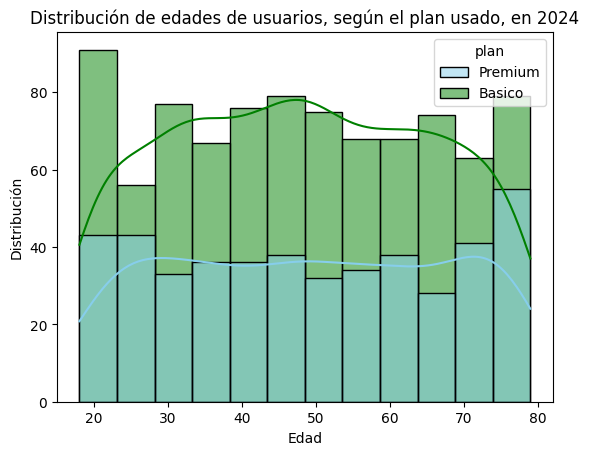

In [39]:
# Historiograma para visulizar la edad (age)
sns.histplot(data=user_profile_2024, x="age", hue="plan", bins=(12), palette=["skyblue", "green"], kde=True)
plt.xlabel("Edad")
plt.ylabel("Distribución")
plt.title("Distribución de edades de usuarios, según el plan usado, en 2024")
plt.show()

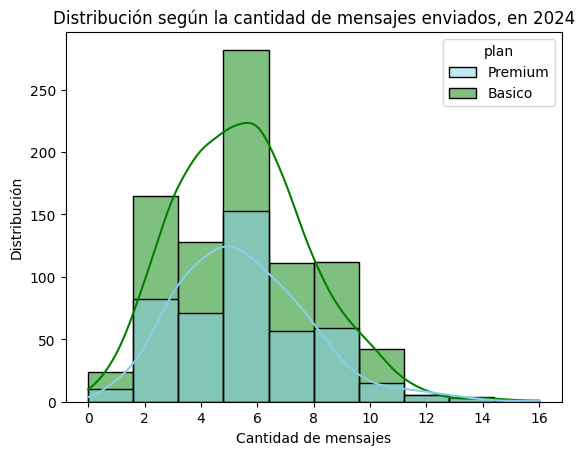

In [40]:
# Historiograma para visulizar la cant_mensajes
sns.histplot(data=user_profile_2024, x="cant_mensajes", hue="plan", bins=(10), palette=["skyblue", "green"], kde=True)
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Distribución")
plt.title("Distribución según la cantidad de mensajes enviados, en 2024")
plt.show()

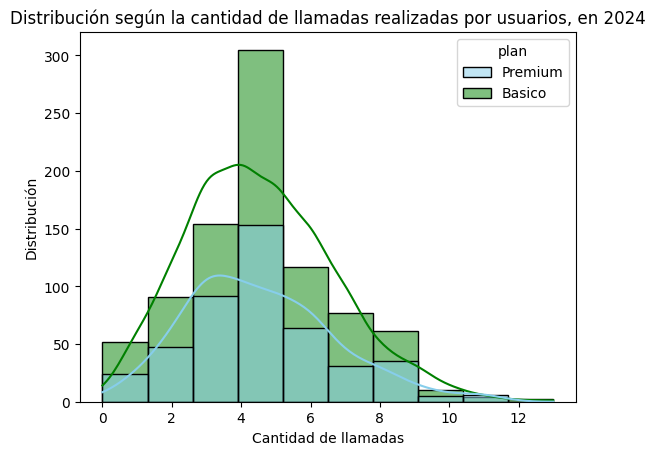

In [41]:

# Historiograma para visulizar la cant_llamadas
sns.histplot(data=user_profile_2024, x="cant_llamadas", hue="plan", bins=(10), palette=["skyblue", "green"], kde=True)
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Distribución")
plt.title("Distribución según la cantidad de llamadas realizadas por usuarios, en 2024")
plt.show()


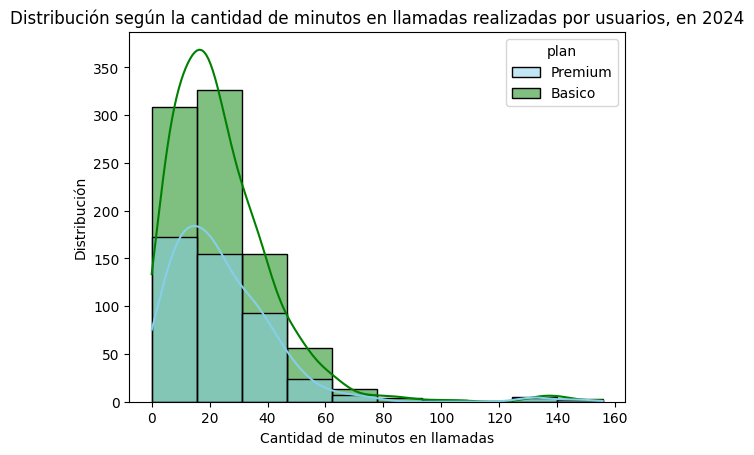

In [42]:
# Historiograma para visulizar la cant_minutos_llamadas
sns.histplot(data=user_profile_2024, x="cant_minutos_llamadas", hue="plan", bins=(10), palette=["skyblue", "green"], kde=True)
plt.xlabel("Cantidad de minutos en llamadas")
plt.ylabel("Distribución")
plt.title("Distribución según la cantidad de minutos en llamadas realizadas por usuarios, en 2024")
plt.show()


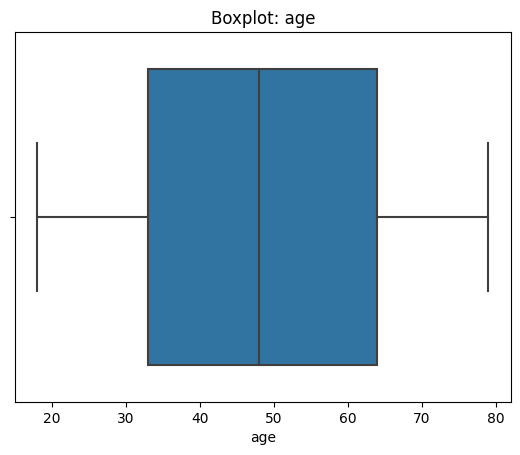

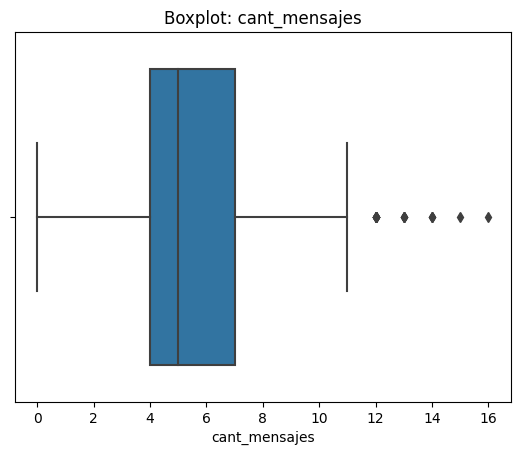

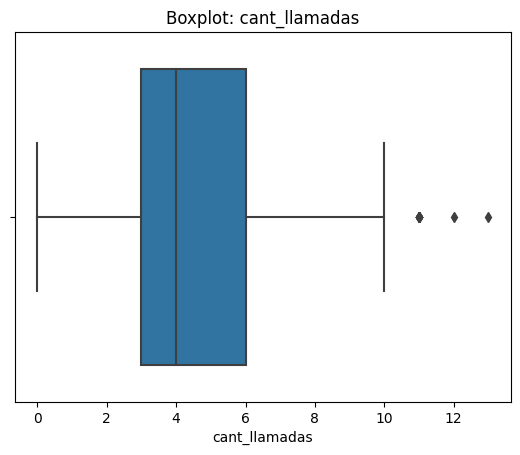

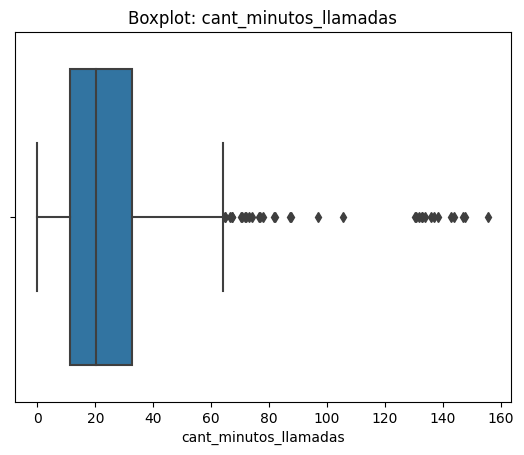

In [43]:

# Identificación de outliers
columnas = ["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamadas"]

for col in columnas:
    sns.boxplot(data=user_profile_2024, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()


In [44]:

# Calculo de outliers de cant_mensajes
columnas = ["cant_mensajes", "cant_llamadas", "cant_minutos_llamadas"]
for col in columnas:
    Q1 = user_profile_2024[col].quantile(0.25)
    Q3 = user_profile_2024[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    print (f'Limite superior de {col}: {upper:.2f}')



Limite superior de cant_mensajes: 11.50
Limite superior de cant_llamadas: 10.50
Limite superior de cant_minutos_llamadas: 64.36


In [45]:
# segmanetación de clientes
def segmentacion_clientes (row):
    llamadas = row["cant_llamadas"]
    mensajes = row["cant_mensajes"]

    if pd.isna(llamadas) or pd.isna(mensajes):
        return "Error en datos"

    if llamadas < 5 and mensajes < 5:
            return "Bajo uso"
    elif llamadas < 10 and mensajes < 10:
            return "Uso medio"
    else:
        return "Alto uso"
user_profile_2024["grupo_uso"] = user_profile_2024.apply(segmentacion_clientes, axis=1)
user_profile_2024.head()


,index,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamadas,grupo_uso
0,2665,12666,Mateo,Garcia,20.0,Cali,2024-01-01 00:00:00.000000000,Premium,NaN,13,3,11.50,Alto uso
1,2666,12667,Carlos,Gomez,72.0,Cali,2024-01-01 06:34:17.914478624,Premium,NaN,3,7,33.27,Uso medio
2,2667,12668,Ana,Torres,21.0,CDMX,2024-01-01 13:08:35.828957240,Basico,NaN,5,7,87.56,Uso medio
3,2668,12669,Sofia,Garcia,58.0,CDMX,2024-01-01 19:42:53.743435864,Basico,NaN,4,5,27.62,Uso medio
4,2669,12670,Ana,Garcia,54.0,MTY,2024-01-02 02:17:11.657914480,Premium,NaN,9,4,31.90,Uso medio
